## Probability and Distributions

#### In this notebook, we'll cover statistical concepts, probability, and different types of distributions that can be used to analyse data using the scipy.stats package script in Python

### Learning Objectives
#### By the end of this notebook, you should be able to:
##### - Distinguish between inferential and descriptive statistics
##### - Describe and identify the different variables and data types
##### - Utilise the stats package **scipy.stats** in Python
##### - Understand the concepts of random variables
##### - Understand probability functions
##### - Differentiate and explain different distributions

### Descriptive Statistics

In [35]:
import pandas as pd
import numpy as np

# Deforestation rates (in hectares) in various regions
data = {
    'Region': ['Amazon', 'Congo', 'Southeast Asia', 'Boreal Forests'],
    'Deforestation_rate_2020': [1000, 500, 750, 200],    # Ratio variable
    'Deforestation_rate_2021': [800, 450, 700, 150],     # Ratio variable, assumong a decrease
    'Region_type': ['Tropical', 'Tropical', 'Tropical', 'Temperate']  # Nominal variable
}

df = pd.DataFrame(data)

# Calculate basic descriptive statistics
descriptive_stats = df['Deforestation_rate_2020'].describe()
print(descriptive_stats)

count       4.00000
mean      612.50000
std       342.47871
min       200.00000
25%       425.00000
50%       625.00000
75%       812.50000
max      1000.00000
Name: Deforestation_rate_2020, dtype: float64


### Inferential Statistics

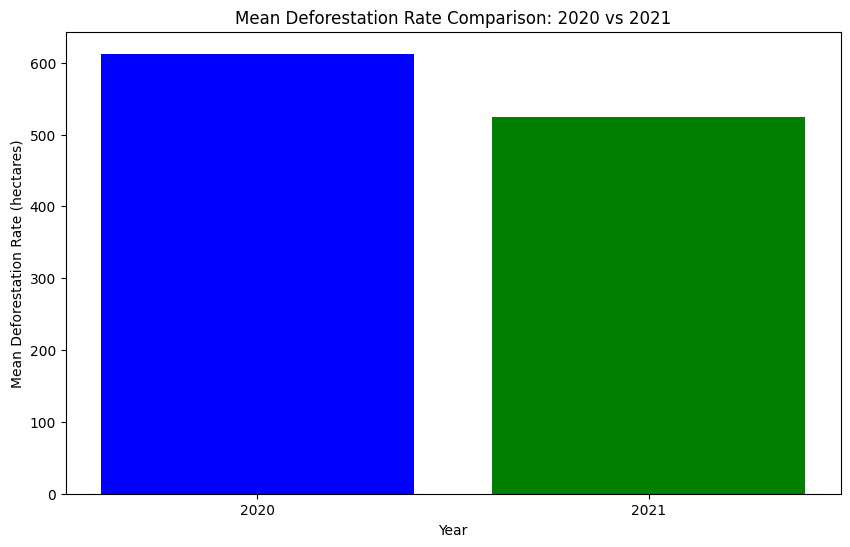

In [36]:
import matplotlib.pyplot as plt

# Calculate mean deforestation rates for 2020 and 2021
mean_deforestation_2020 = np.mean(df['Deforestation_rate_2020'])
mean_deforestation_2021 = np.mean(df['Deforestation_rate_2021'])

# Data for plotting
years = ['2020', '2021']
means = [mean_deforestation_2020, mean_deforestation_2021]

plt.figure(figsize=(10,6))
plt.bar(years, means, color=['blue', 'green'])
plt.xlabel('Year')
plt.ylabel('Mean Deforestation Rate (hectares)')
plt.title('Mean Deforestation Rate Comparison: 2020 vs 2021')
plt.xticks(years)
plt.show()

In [37]:
df['Average_Rainfall_mm'] = [2300, 1600, 2500, 500]
df['Protected_Area'] = [True, False, True, True]
df['Biodiversity_Index'] = [8.5, 7.0, 9.0, 6.5]
df['Conservation_Status'] = ['High', 'Medium', 'Low', 'Medium']
# Mapping an ordinal variable to an ordered numerical representation
conservation_mapping = {'Low': 1, 'Medium': 2, 'High': 3}
df['Conservation_Status_Mapped'] = df['Conservation_Status'].map(conservation_mapping)

print(df)

           Region  Deforestation_rate_2020  Deforestation_rate_2021  \
0          Amazon                     1000                      800   
1           Congo                      500                      450   
2  Southeast Asia                      750                      700   
3  Boreal Forests                      200                      150   

  Region_type  Average_Rainfall_mm  Protected_Area  Biodiversity_Index  \
0    Tropical                 2300            True                 8.5   
1    Tropical                 1600           False                 7.0   
2    Tropical                 2500            True                 9.0   
3   Temperate                  500            True                 6.5   

  Conservation_Status  Conservation_Status_Mapped  
0                High                           3  
1              Medium                           2  
2                 Low                           1  
3              Medium                           2  


### Probability - The chance of everything happening

In [38]:
import numpy as np
import scipy.stats as st
import matplotlib.pyplot as plt

### Distributions in Statistics

#### Normal Distribution

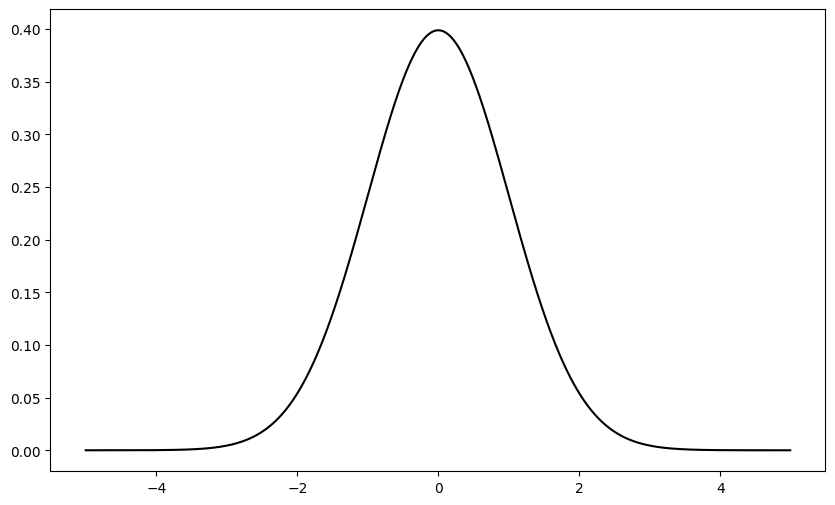

In [39]:
# Standard normal distribution plot
x = np.arange(-5,5,0.01)    # range of values for z
mu = 0                      # mu = 0 for standard normal
sigma = 1                   # mu = 1 for standard normal

# now calculate f(x)
f = 1 / np.sqrt((2 * np.pi * sigma ** 2)) * np.exp(-0.5 * ((x - mu) / sigma) ** 2)

plt.rcParams["figure.figsize"] = (10,6)
plt.plot(x,f,'k')
plt.show()

In [40]:
def normal_prob(x1, x2, mu, sigma):
    return (st.norm.cdf(x2, mu, sigma) - st.norm.cdf(x1, mu, sigma))

normal_prob(2, 5, mu, sigma)

0.022749845296607285

In [41]:
# Add temperature data
df['Average_Temperature'] = [25, 24, 27, -5]    # Average annual temperature (°C)
df['Temperature_Std_Dev'] = [2, 1.5, 2.5, 3]    # Standard deviation of temperature

In [43]:
from scipy.stats import norm

# Example: Probability of experiencing temperatures above 30°C in Southeast Asia
region = 'Southeast Asia'
mean_temp = df.loc[df['Region'] == region, 'Average_Temperature'].values[0]
std_dev_temp = df.loc[df['Region'] == region, 'Temperature_Std_Dev'].values[0]

# Probability of temperature exceeding 30°C
prob_above_30 = 1 - norm.cdf(30, mean_temp, std_dev_temp)
print(f"Probability of temperature above 30°C in {region}: {prob_above_30:.2f}")

Probability of temperature above 30°C in Southeast Asia: 0.12


In [44]:
# Example: Probability of deforestation rate reduction
from scipy.stats import norm

# Assuming deforestation rate reduction follows a normal distribution
mean_reduction = 250  # Mean reduction in hectares
std_deviation = 50    # Standard deviation

# Probability of observing a reduction greater than 300 hectares
prob_greater_than_300 = 1 - norm.cdf(300, mean_reduction, std_deviation)
print(f"Probability of reduction greater than 300 hectares: {prob_greater_than_300:.2f}")

Probability of reduction greater than 300 hectares: 0.16


### Binomial Distribution

#### - The binomial distribution is a foundational concept in statistics, particularly useful in scenarios where we have a series of independent experiments or trials with two possible outcomes: success or failure

#### - This distribution allows for the calculation of the probability of obtaining a specific number of successes in a fixed number of trials, assuming each trial is independent and the probability of success remains constant throughout the trials.

In [46]:
from scipy.stats import binom
k = 10
n = 50    # number of trials
p = 0.2   # Probability of success

# Probability of exactly 10 successes (finding the species in 10 areas)
prob_exactly_10 = binom.pmf(k,n,p)
print(f"Probability of finding the species in exactly 10 out of 50 areas: {prob_exactly_10:.4f}")

Probability of finding the species in exactly 10 out of 50 areas: 0.1398


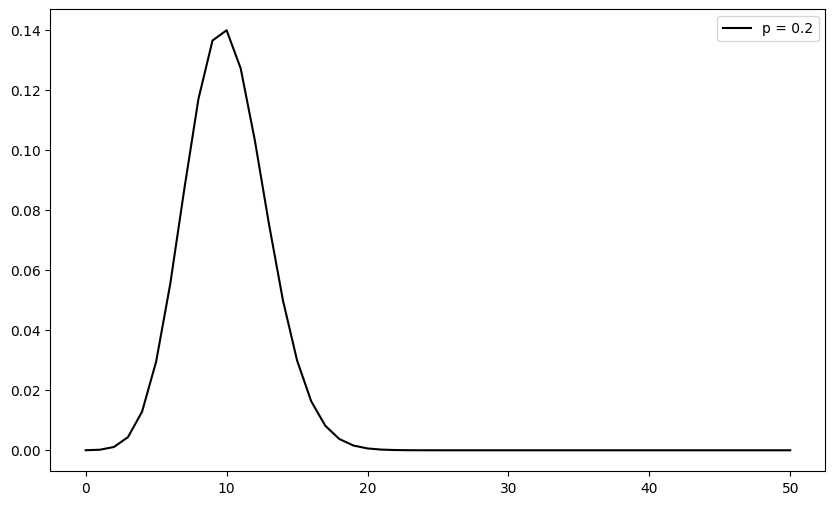

In [47]:
# The PMF
n = 50
x = np.arange(0,51)
p1 = 0.2
px1 = st.binom.pmf(x,n,p1)

plt.rcParams["figure.figsize"] = (10,6)
plt.plot(x, px1, 'k', label='p = 0.2')
plt.legend()
plt.show()

### Poisson Distribution

#### This distribution is particularly helpful when modelling the number of events occurring within a fixed interval of time or space when these events happen independently of each other at a constant average rate.

In [48]:
from scipy.stats import poisson

lambda_illegal_logging = 5    # average number of illegal loggin incidents per month

# Probability of observing exactly 3 illegal logging incidents in a month
prob_exactly_3 = poisson.pmf(3, lambda_illegal_logging)
print(f"Probability of observing exactly 3 illegal logging incidents in a month: {prob_exactly_3:.4f}")

Probability of observing exactly 3 illegal logging incidents in a month: 0.1404


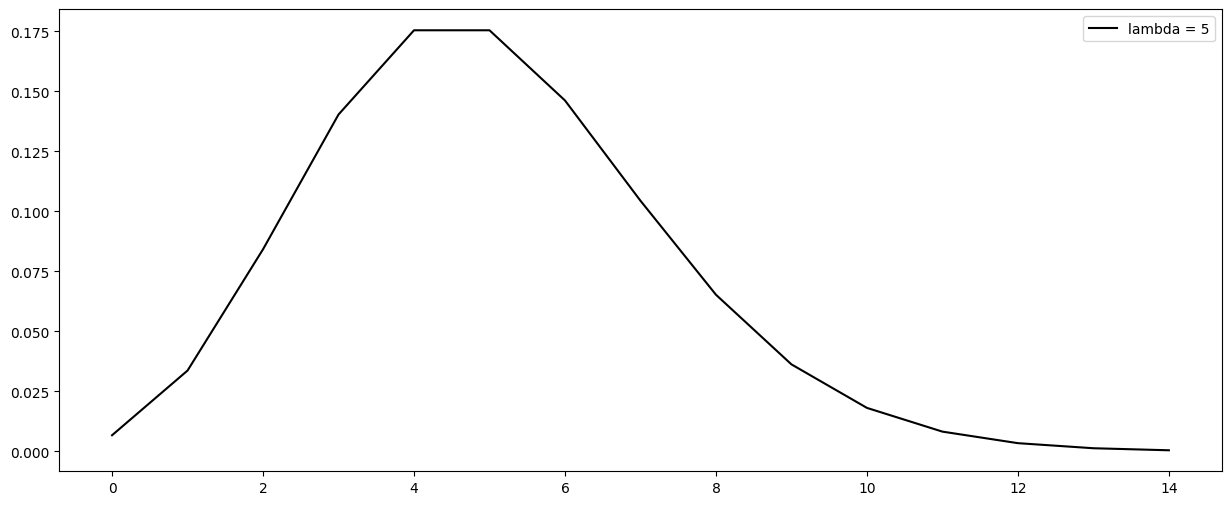

In [49]:
# Looking at the PMF for this distribution
poisson_lambda = 5
x = np.arange(0,15)
px = st.poisson.pmf(x, poisson_lambda)

plt.rcParams["figure.figsize"] = (15,6)
plt.plot(x, px, 'k', label = 'lambda = 5')
plt.legend()
plt.show()

In [50]:
# Probability of observing more than 7 illegal logging incidents in a month
prob_more_than_7 = 1 - poisson.cdf(7, lambda_illegal_logging)
print(f"Probability of observing more than 7 illegal logging incidents in a month: {prob_more_than_7:.4f}")

Probability of observing more than 7 illegal logging incidents in a month: 0.1334


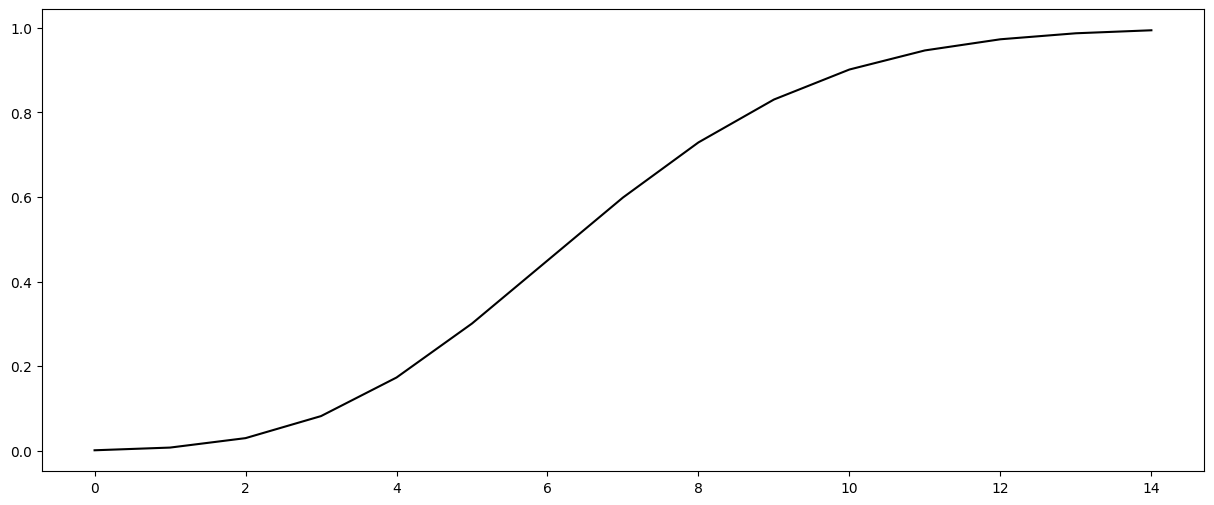

In [51]:
# Displaying the cumulative density function for this distribution
poisson_lambda = 7
x = np.arange(0,15)
px = st.poisson.cdf(x, poisson_lambda)

plt.rcParams["figure.figsize"] = (15,6)
plt.plot(x, px, 'k', label = 'lambda = 7')
plt.show()

### Negative binomial distribution

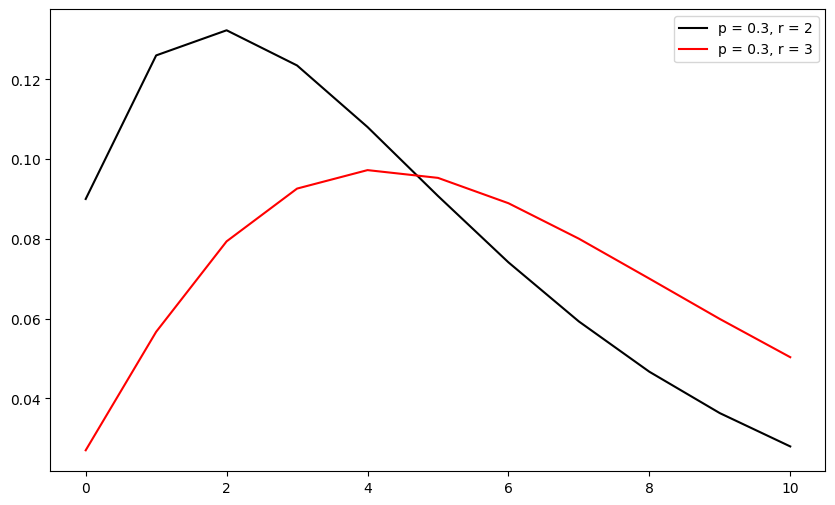

In [52]:
# PMF for negative binomial distribution
p = 0.3
x = np.arange(0,11)
r1 = 2
px1 = st.nbinom.pmf(x, r1, p)
r2 = 3
px2 = st.nbinom.pmf(x, r2, p)

plt.rcParams["figure.figsize"] = (10,6)
plt.plot(x, px1, 'k', label = 'p = 0.3, r = 2')
plt.plot(x, px2, 'r', label = 'p = 0.3, r = 3')
plt.legend()
plt.show()

### Exponential Distribution

#### In this distribution, rather than modelling the number of events in a time period as in Poisson, we are interested in the time interval between events

In [54]:
from scipy.stats import expon

# Average time between forest fires is 10 years, so the rate λ = 0.1 per year
lambda_fire = 0.1
scale_fire = 1 / lambda_fire    # Scale parameter for the exponential distribution is the inverse of λ

# Probability of a forest fire occurring within the next 5 years
prob_within_5_years_fire = expon.cdf(5, scale=scale_fire)
print(f"Probability of a forest fire occurring within the next 5 years: {prob_within_5_years_fire:.4f}")

Probability of a forest fire occurring within the next 5 years: 0.3935


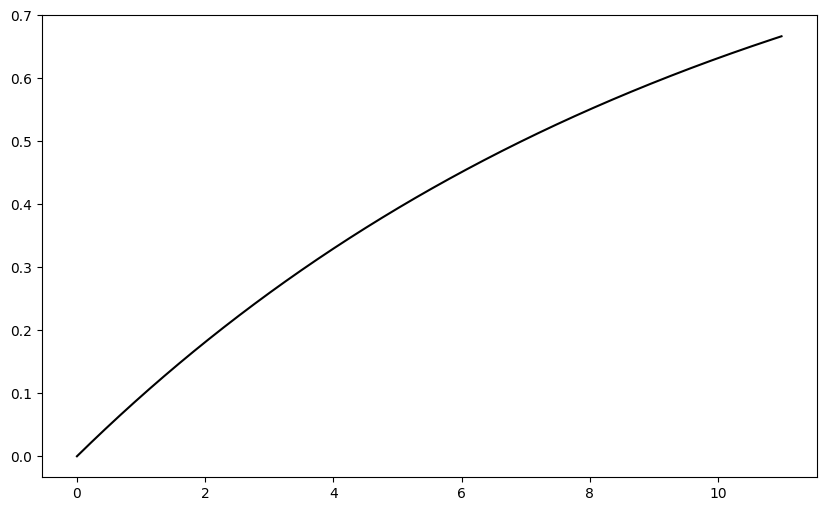

In [55]:
# The cdf for the exponential distribution
lambda_var = 0.1
x = np.arange(0, 11, 0.01)
dx = st.expon.cdf(x, scale = 1/lambda_var)

plt.rcParams["figure.figsize"] = (10,6)
plt.plot(x, dx, 'k')
plt.show()

### Uniform Distribution

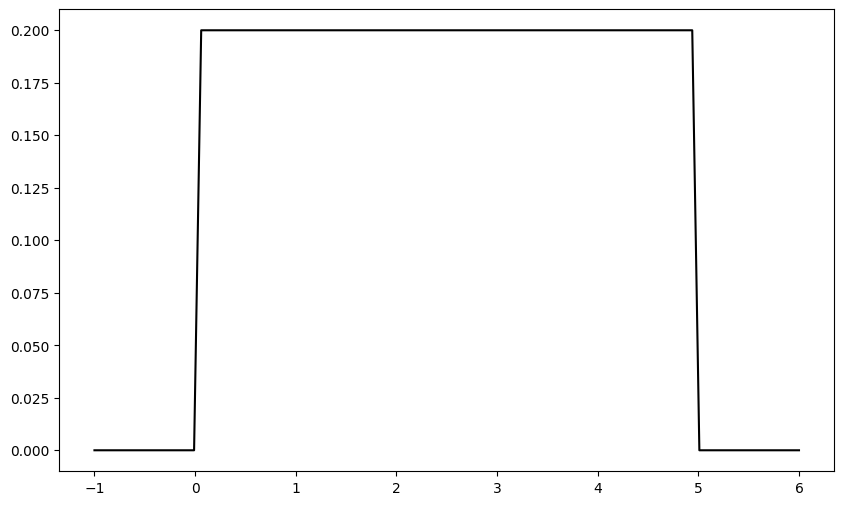

In [56]:
a = 0
b = 5

x = np.linspace(a-1, b+1, 100)
y = st.uniform.pdf(x, loc=a, scale=b-a)

plt.plot(x, y, 'k')

In [57]:
a = 0
b = 5
c = 2
d = 3

st.uniform.cdf(d, loc = a, scale = b-a) - st.uniform.cdf(c, loc = a, scale = b-a)

0.19999999999999996